In [3]:
# =============
# CARGA DE LIBRERIAS

from astropy.io import fits
import gc
import math
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import pickle
import random
from tqdm import tqdm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

In [ ]:
# =============
# CARGA DE DATASETS

# Definir la clase Dataset
class SpectraDataset(Dataset):
    def __init__(self, dataset_path):
        # Cargamos el diccionario previamente guardado (.pt)
        data = torch.load(dataset_path)
        self.flux = data["flux"]          # Tensor con forma [N, num_points]
        self.wavelength = data["wavelength"]  # Tensor con forma [N, num_points]
        self.redshift = data["redshift"]      # Tensor con forma [N]
    
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Rutas a los archivos preprocesados
data_dir = "data"
train_dataset_path = os.path.join(data_dir, "train_dataset_1M.pt")
test_dataset_path  = os.path.join(data_dir, "test_dataset_1M.pt")

# Crear los datasets
train_dataset = SpectraDataset(train_dataset_path)
test_dataset  = SpectraDataset(test_dataset_path)

# Crear DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

In [5]:
# =============
# DEFINICIÓN Y CONFIGURACIÓN DEL MODELO

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Número de puntos en cada espectro
num_points = 5000

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

# Instanciar el modelo y moverlo a GPU si está disponible
modelCNN = CNN(num_points).to(device)
criterion = nn.L1Loss()
optimizer = optim.Adam(modelCNN.parameters(), lr=0.0001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

print("Modelo configurado correctamente.")

Usando dispositivo: cuda
Modelo configurado correctamente.


In [6]:
# =============
# INICIALIZACIÓN DEL MODELO

num_epochs = 1
best_val_loss = float('inf')  # Para almacenar la mejor pérdida de validación

for epoch in range(num_epochs):
    modelCNN.train()
    running_loss = 0.0
    
    # Bucle de entrenamiento con barra de progreso
    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Entrenamiento"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validación"):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}", flush=True)
    
    # Guardar el checkpoint si hay mejora en la pérdida de validación
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': modelCNN.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }
        torch.save(checkpoint, 'storage/modelCNN_600k_1.pth')
        print("Checkpoint guardado con éxito.")

# Evaluación final en el conjunto de prueba utilizando MAE
modelCNN.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.4f}")

Epoch 1/1 - Validación: 100%|██████████| 2978/2978 [00:07<00:00, 419.18it/s]

Epoch 1/1 - Loss: 0.2224, Val Loss: 0.4695, LR: 0.0001000000


Checkpoint guardado con éxito.
Error absoluto medio en el conjunto de prueba: 0.4695


In [7]:
# =============
# ENTRENAMIENTO GRUESO DEL MODELO (SE HACE ASÍ PARA PODER ENTRENARLO POCO A POCO)

# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelCNN_600k_1.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
start_epoch = checkpoint['epoch']

# Definir el número total de epochs que deseas entrenar
num_epochs = 30
best_val_loss = float('inf')  # Para guardar el checkpoint en caso de mejora

# Continuar el entrenamiento desde el epoch donde se quedó
for epoch in range(start_epoch, num_epochs):
    modelCNN.train()
    running_loss = 0.0
    
    # Bucle de entrenamiento con barra de progreso
    for batch_X, batch_y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Entrenamiento"):
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_X.size(0)
    epoch_loss = running_loss / len(train_dataset)
    
    # Evaluación en el conjunto de validación
    modelCNN.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch_X, batch_y in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} - Validación"):
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = modelCNN(batch_X)
            loss = criterion(outputs, batch_y)
            val_loss += loss.item() * batch_X.size(0)
    val_loss /= len(test_dataset)
    
    # Actualizar la tasa de aprendizaje según la pérdida de validación
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}, Val Loss: {val_loss:.4f}, LR: {current_lr:.10f}")
    
    # Guardar el checkpoint si hay mejora en la pérdida de validación
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        checkpoint = {
            'epoch': epoch + 1,
            'model_state_dict': modelCNN.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict()
        }
        torch.save(checkpoint, 'storage/modelCNN_600k_1.pth')
        print("Checkpoint guardado con éxito.")

# Evaluación final en el conjunto de prueba utilizando MAE
modelCNN.eval()
test_loss = 0.0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        outputs = modelCNN(batch_X)
        loss = criterion(outputs, batch_y)
        test_loss += loss.item() * batch_X.size(0)
test_loss /= len(test_dataset)
print(f"Error absoluto medio en el conjunto de prueba: {test_loss:.4f}")

# Guardar los parámetros finales del modelo
checkpoint = {
    'epoch': num_epochs,
    'model_state_dict': modelCNN.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict()
}
torch.save(checkpoint, 'storage/modelCNN_600k_1.pth')

Epoch 2/30 - Validación: 100%|██████████| 2978/2978 [00:07<00:00, 407.35it/s]


Epoch 2/30, Loss: 0.1719, Val Loss: 0.8083, LR: 0.0001000000
Checkpoint guardado con éxito.


Epoch 3/30 - Validación: 100%|██████████| 2978/2978 [00:07<00:00, 410.54it/s]


Epoch 3/30, Loss: 0.1502, Val Loss: 1.5742, LR: 0.0001000000


Epoch 4/30 - Validación: 100%|██████████| 2978/2978 [00:07<00:00, 411.85it/s]


...

Epoch 28/30, Loss: 0.1012, Val Loss: 0.7216, LR: 0.0000250000


Epoch 29/30 - Validación: 100%|██████████| 2978/2978 [00:06<00:00, 429.74it/s]


Epoch 29/30, Loss: 0.1009, Val Loss: 0.3971, LR: 0.0000250000


Epoch 30/30 - Validación: 100%|██████████| 2978/2978 [00:06<00:00, 433.05it/s]


Epoch 30/30, Loss: 0.1009, Val Loss: 0.7487, LR: 0.0000250000
Error absoluto medio en el conjunto de prueba: 0.7487


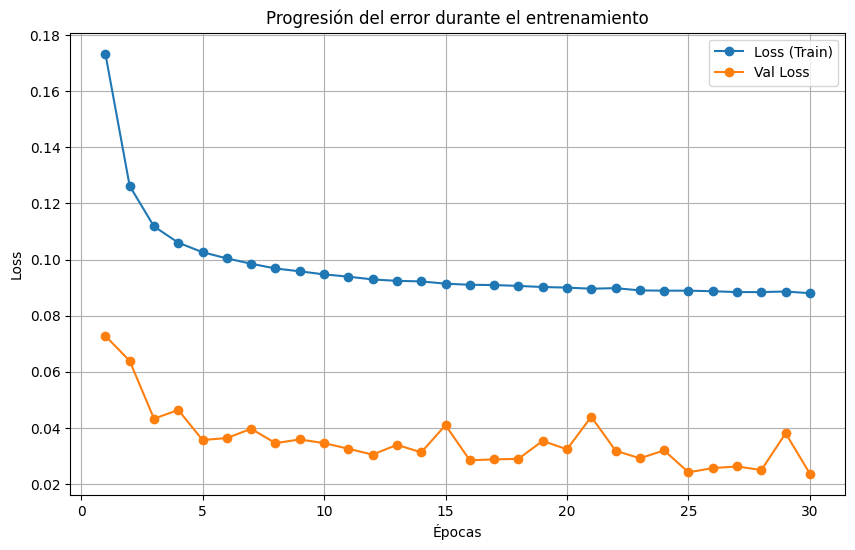

In [8]:
import matplotlib.pyplot as plt

# Datos extraídos de los logs
epochs = list(range(1, 31))
loss = [0.1733, 0.1262, 0.1118, 0.1060, 0.1026, 0.1004, 0.0985, 0.0968, 0.0958, 0.0947, 
        0.0939, 0.0929, 0.0924, 0.0922, 0.0914, 0.0910, 0.0909, 0.0906, 0.0902, 0.0900, 
        0.0896, 0.0898, 0.0890, 0.0889, 0.0889, 0.0887, 0.0884, 0.0884, 0.0886, 0.0880]
val_loss = [0.0728, 0.0639, 0.0433, 0.0464, 0.0357, 0.0364, 0.0397, 0.0346, 0.0359, 0.0346, 
            0.0326, 0.0305, 0.0340, 0.0313, 0.0410, 0.0285, 0.0288, 0.0290, 0.0354, 0.0324, 
            0.0440, 0.0319, 0.0292, 0.0320, 0.0242, 0.0257, 0.0263, 0.0250, 0.0381, 0.0237]

# Crear la gráfica
plt.figure(figsize=(10,6))
plt.plot(epochs, loss, marker='o', label='Loss (Train)')
plt.plot(epochs, val_loss, marker='o', label='Val Loss')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('Progresión del error durante el entrenamiento')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATASETS USADOS HASTA AHORA

# Cargar checkpoint y estados del modelo, optimizador y scheduler
checkpoint = torch.load('storage/modelCNN_600k_1.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])

all_preds = []
all_y = []
with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        preds = modelCNN(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())
    for inputs, targets in train_loader:
        inputs = inputs.to(device)
        preds = modelCNN(inputs).cpu().numpy()  # forma: (batch_size, 1)
        all_preds.append(preds)
        all_y.append(targets.numpy())

# Concatenar y convertir a vectores 1D (aplicamos squeeze a ambos)
preds_all = np.concatenate(all_preds, axis=0).squeeze()
y_all = np.concatenate(all_y, axis=0).squeeze()

# Calcular la correlación lineal
corr = np.corrcoef(y_all, preds_all)[0, 1]
print(f"Correlación lineal: {corr:.4f}")

slope, intercept = np.polyfit(y_all, preds_all, 1)
print("Slope:", slope)
print("Intercept:", intercept)

Correlación lineal: 0.0074
Slope: 0.755272478753119
Intercept: 0.25907600820921906


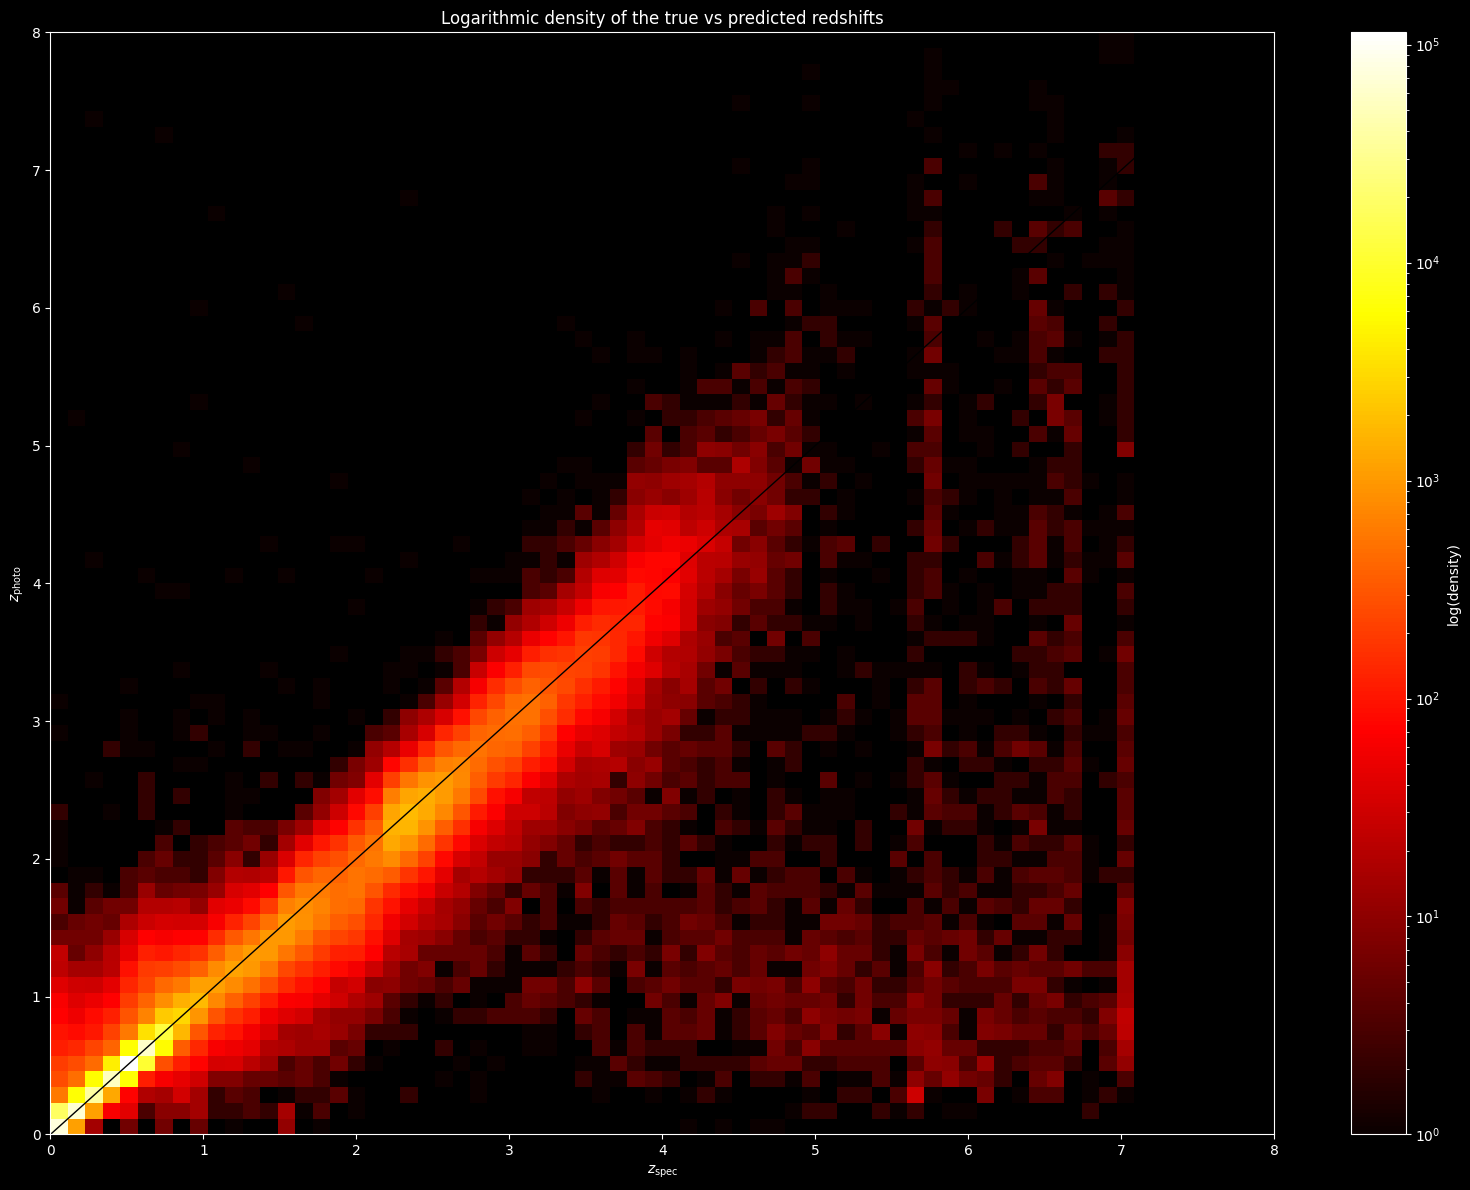

In [10]:
# Mapa de calor de z_real frente a z_predicho éstandar
plt.style.use('dark_background')
x_min, x_max = 0, 8
y_min, y_max = 0, 8
# x_min, x_max = 0, 1
# y_min, y_max = 0, 1
# x_min, x_max = 1, 4
# y_min, y_max = 1, 4
# x_min, x_max = 4, 8
# y_min, y_max = 4, 8
plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    y_all,                 # z_spec (redshift "real")
    preds_all,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)
cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

In [ ]:
# =============
# EVALUACIÓN Y REPRESENTACIÓN EN BASE A LOS DATOS COMPLETOS DE LA SDSS

from astropy.io import fits
import gc
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np
import os
import pickle
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

del train_dataset, test_dataset, train_loader, test_loader
torch.cuda.empty_cache()
gc.collect()

# Configurar dispositivo para GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Definir la clase del Dataset para tensores (no listas)
class SpectraDataset(Dataset):
    def __init__(self, flux_pt_path, wavelength_pt_path, redshift_pt_path):
        # Cargar los tensores previamente guardados
        self.flux = torch.load(flux_pt_path)         # Tensor de forma (num_samples, num_points)
        self.wavelength = torch.load(wavelength_pt_path)
        self.redshift = torch.load(redshift_pt_path)   # Tensor de forma (num_samples, 1) o (num_samples,)
        
    def __len__(self):
        return self.flux.shape[0]
    
    def __getitem__(self, idx):
        # Combina flux y wavelength en un tensor de entrada de dos canales
        input_sample = torch.stack([self.flux[idx], self.wavelength[idx]], dim=0)  # [2, num_points]
        target = self.redshift[idx]
        return input_sample, target

# Definir el modelo CNN en PyTorch con dropout para regularización
class CNN(nn.Module):
    def __init__(self, num_points):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv1d(in_channels=2, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        # Con 5 capas de max pooling, la dimensión se reduce en un factor de 2^5 = 32
        conv_output_size = num_points // 32
        self.fc_layers = nn.Sequential(
            nn.Linear(256 * conv_output_size, 128),
            nn.ReLU(),
            nn.Dropout(p=0.5),  # Regularización con Dropout
            nn.Linear(128, 1)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

num_points = 5000 # Número de puntos en cada espectro
modelCNN = CNN(num_points).to(device)

data_dir  = "data"
storage_dir = "storage"
batch_size = 32 # Parámetro de batch
model_checkpoint = 'storage/modelCNN_600k_1.pth' # Ruta del checkpoint del modelo

# Instanciar el modelo y cargar el checkpoint
modelCNN = CNN(num_points).to(device)
checkpoint = torch.load(model_checkpoint, map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
modelCNN.eval()


# Evaluación de la primera mitad (Half 1)

# Rutas para la primera mitad
flux_pt_path1       = os.path.join(data_dir, "spectra_data_complete_flux1.pt")
wavelength_pt_path1 = os.path.join(data_dir, "spectra_data_complete_wavelength1.pt")
redshift_pt_path1   = os.path.join(data_dir, "spectra_data_complete_redshift1.pt")

# Crear dataset y dataloader para la primera mitad
dataset1 = SpectraDataset(flux_pt_path1, wavelength_pt_path1, redshift_pt_path1)
dataloader1 = DataLoader(dataset1, batch_size=batch_size, shuffle=False)

predicted1 = []
real1 = []

with torch.no_grad():
    for x_batch, y_batch in dataloader1:
        x_batch = x_batch.to(device)
        preds = modelCNN(x_batch).cpu().numpy()  # forma: (batch_size, 1)
        predicted1.append(preds)
        real1.append(y_batch.numpy())

# Concatenar los resultados de la primera mitad
predicted1 = np.concatenate(predicted1, axis=0)
real1 = np.concatenate(real1, axis=0)

# Guardar los resultados en archivos .npy
np.save(os.path.join(storage_dir, "predicted1_CNN600k_1.npy"), predicted1)
np.save(os.path.join(storage_dir, "real1_CNN600k_1.npy"), real1)

print("Evaluación de la primera mitad completada y resultados guardados.")

# Liberar memoria
del dataset1, dataloader1
torch.cuda.empty_cache()
gc.collect()


# Evaluación de la segunda mitad (Half 2)

# Rutas para la segunda mitad
flux_pt_path2       = os.path.join(data_dir, "spectra_data_complete_flux2.pt")
wavelength_pt_path2 = os.path.join(data_dir, "spectra_data_complete_wavelength2.pt")
redshift_pt_path2   = os.path.join(data_dir, "spectra_data_complete_redshift2.pt")

# Crear dataset y dataloader para la segunda mitad
dataset2 = SpectraDataset(flux_pt_path2, wavelength_pt_path2, redshift_pt_path2)
dataloader2 = DataLoader(dataset2, batch_size=batch_size, shuffle=False)

predicted2 = []
real2 = []

with torch.no_grad():
    for x_batch, y_batch in dataloader2:
        x_batch = x_batch.to(device)
        preds = modelCNN(x_batch).cpu().numpy()
        predicted2.append(preds)
        real2.append(y_batch.numpy())

# Concatenar los resultados de la segunda mitad
predicted2 = np.concatenate(predicted2, axis=0)
real2 = np.concatenate(real2, axis=0)

# Guardar los resultados en archivos .npy
np.save(os.path.join(storage_dir, "predicted2_CNN600k_1.npy"), predicted2)
np.save(os.path.join(storage_dir, "real2_CNN600k_1.npy"), real2)

print("Evaluación de la segunda mitad completada y resultados guardados.")

# Liberar memoria
del dataset2, dataloader2
torch.cuda.empty_cache()
gc.collect()

Usando dispositivo: cuda


In [ ]:
# Cargar los datos guardados
predicted1 = np.load(os.path.join(storage_dir, "predicted1_CNN600k_1.npy"))
real1      = np.load(os.path.join(storage_dir, "real1_CNN600k_1.npy"))
predicted2 = np.load(os.path.join(storage_dir, "predicted2_CNN600k_1.npy"))
real2      = np.load(os.path.join(storage_dir, "real2_CNN600k_1.npy"))

# Concatenar ambos resultados
ypredicted = np.concatenate([predicted1, predicted2], axis=0)
yreal      = np.concatenate([real1, real2], axis=0)

# Asegurarse de que ambos sean vectores 1D
ypredicted = ypredicted.squeeze()     # Ahora tiene forma (N,)
yreal      = yreal.squeeze()          # Ahora tiene forma (N,)

# Calcular la correlación lineal
correlation = np.corrcoef(yreal, ypredicted)[0, 1]

print(f"Correlación lineal: {correlation:.4f}")
print(f"Número de muestras evaluadas: {len(yreal)}")

# Dispersión de puntos de z_real frente a z_predicho

plt.rcdefaults()
plt.figure(figsize=(16, 12))
plt.scatter(yreal, ypredicted, alpha=0.6, label='Datos')
plt.xlabel('Redshift Real')
plt.ylabel('Redshift Predicho')
plt.title('Comparación entre Redshift Real y Predicho')
# Añadir la línea ideal (y=x)
min_val = min(yreal.min(), ypredicted.min())
max_val = max(yreal.max(), ypredicted.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal')
plt.legend()
plt.grid(True)
plt.xlim(0, 8)
plt.ylim(0, 8)
plt.show()






# Mapa de calor de z_real frente a z_predicho éstandar

plt.style.use('dark_background')

x_min, x_max = 0, 8
y_min, y_max = 0, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar negatividad

plt.style.use('dark_background')

x_min, x_max = -1, 8
y_min, y_max = -1, 0

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos bajos

plt.style.use('dark_background')

x_min, x_max = 0, 1
y_min, y_max = 0, 1

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()






# Mapa de calor de z_real frente a z_predicho para comprobar rangos intermedios

plt.style.use('dark_background')

x_min, x_max = 1, 5
y_min, y_max = 1, 5

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()







# Mapa de calor de z_real frente a z_predicho para comprobar rangos altos

plt.style.use('dark_background')

x_min, x_max = 5, 8
y_min, y_max = 1, 8

plt.figure(figsize=(16, 12))

# Cálculo del histograma 2D con escala logarítmica
counts, xedges, yedges, im = plt.hist2d(
    yreal,                 # z_spec (redshift "real")
    ypredicted,      # z_photo (redshift "predicho")
    bins=70,
    range=[[x_min, x_max], [y_min, y_max]],
    cmap='hot',
    norm=colors.LogNorm()  # Densidad logarítmica
)

cbar = plt.colorbar(im, label='log(density)')

plt.plot([x_min, x_max], [x_min, x_max], color='black', linewidth=1)
plt.xlabel(r'$z_{\mathrm{spec}}$')
plt.ylabel(r'$z_{\mathrm{photo}}$')
plt.title('Logarithmic density of the true vs predicted redshifts')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.tight_layout()
plt.show()

NameError: name 'np' is not defined

Redshift real: 0.47856843
Redshift predicho: 0.48358064889907837


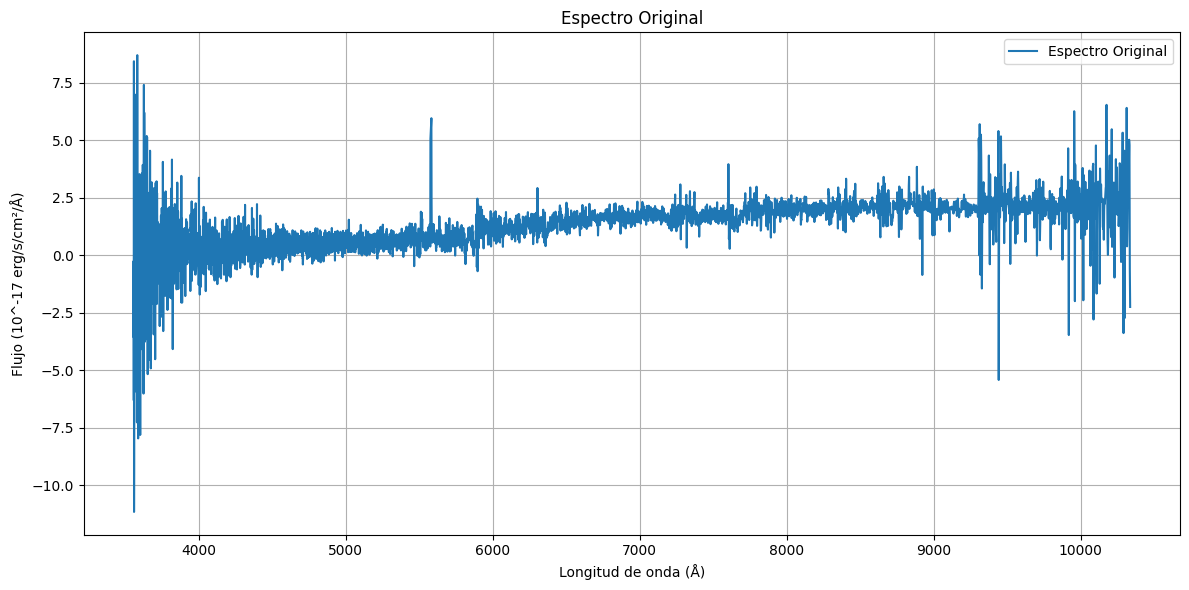

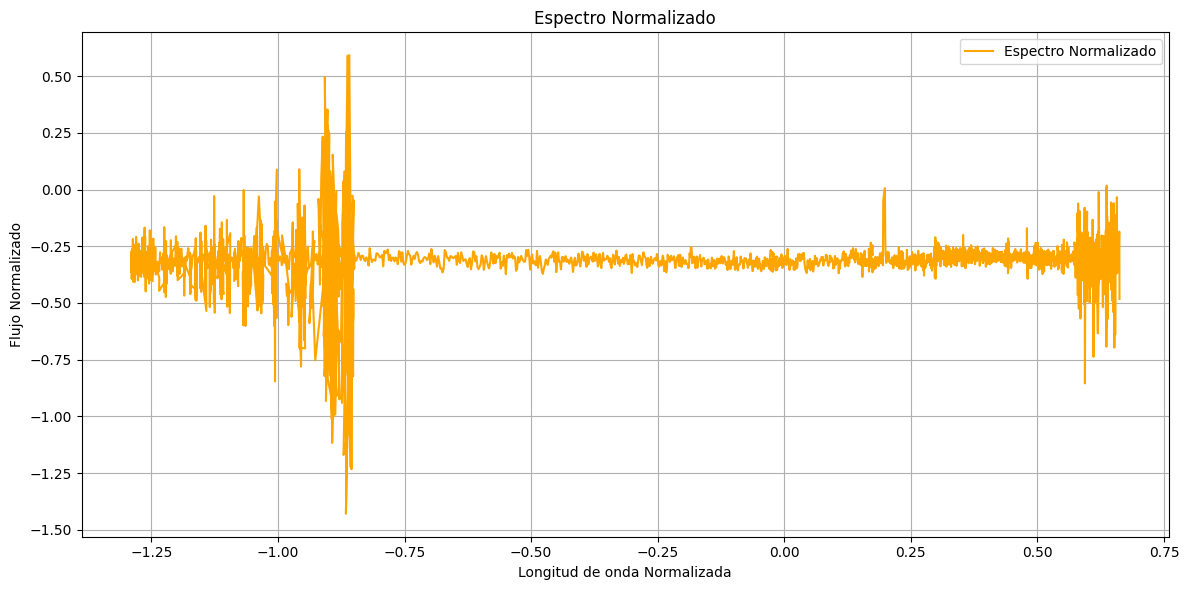

In [ ]:
# Obtener la lista inicial de archivos FITS
folder_path = r'spectrums'
files = [f for f in os.listdir(folder_path) if f.endswith('.fits')]
files = random.sample(files, len(files))
file_path = os.path.join(folder_path, files[0])

# Cargar el checkpoint del modelo y los escaladores
checkpoint = torch.load('storage/modelCNN_600k_1.pth', map_location=device)
modelCNN.load_state_dict(checkpoint['model_state_dict'])
modelCNN.eval()

# Los escaladores se encuentran en un diccionario con las claves "flux_scaler" y "wavelength_scaler"
with open('extra/scaler_fitted.pkl', 'rb') as f:
    scaler_dict = pickle.load(f)
flux_scaler = scaler_dict["flux_scaler"]
wavelength_scaler = scaler_dict["wavelength_scaler"]

# Abrir el archivo FITS y extraer datos
with fits.open(file_path) as hdul:
    test_flux = hdul[1].data["flux"]
    test_loglam = hdul[1].data["loglam"]
    test_redshift = hdul[2].data["Z"][0]

# Convertir loglam a wavelength
test_wavelength = 10 ** test_loglam

def expand_points(wavelength, flux, target_count=5000):
    # Convertir a listas para facilitar las inserciones
    wl = list(wavelength)
    fl = list(flux)
    
    # Calcular las diferencias absolutas entre puntos consecutivos
    diffs = [abs(fl[i+1] - fl[i]) for i in range(len(fl)-1)]
    # Obtener los índices ordenados de mayor a menor diferencia
    sorted_indices = sorted(range(len(diffs)), key=lambda i: diffs[i], reverse=True)
    
    # Insertar nuevos puntos utilizando los índices ordenados
    while len(wl) < target_count:
        # Se recorre la lista de índices en orden descendente para evitar problemas con el reordenamiento
        for idx in sorted_indices:
            if len(wl) >= target_count:
                break
            # Calcular la interpolación lineal entre el punto idx y el siguiente
            new_wl = (wl[idx] + wl[idx+1]) / 2
            new_fl = (fl[idx] + fl[idx+1]) / 2
            # Insertar el nuevo punto en la posición correspondiente
            wl.insert(idx+1, new_wl)
            fl.insert(idx+1, new_fl)
    
    return np.array(wl), np.array(fl)

# Asegurarse de tener exactamente num_points
test_wavelength, test_flux = expand_points(test_wavelength, test_flux, target_count=num_points)

# Preprocesamiento para el modelo
# El modelo espera dos canales: canal 0 -> flux y canal 1 -> wavelength.
# Separamos cada canal y aplicamos el escalador correspondiente.
# Cada escalador fue ajustado en datos de forma (n_samples, 5000)

# Redimensionar cada canal para que tenga forma (1, num_points)
input_flux = test_flux.reshape(1, -1)              # (1, 5000)
input_wavelength = test_wavelength.reshape(1, -1)  # (1, 5000)

# Aplicar la normalización con los escaladores correspondientes
flux_scaled = flux_scaler.transform(input_flux)                     # (1, 5000)
wavelength_scaled = wavelength_scaler.transform(input_wavelength)   # (1, 5000)

# Reconstruir el input con dos canales: (2, 5000) y agregar dimensión de batch => (1, 2, 5000)
input_scaled = np.stack([flux_scaled[0], wavelength_scaled[0]], axis=0)
input_scaled = input_scaled.reshape(1, 2, num_points)

# Convertir a tensor (usando torch.from_numpy para no saturar la memoria)
input_tensor = torch.from_numpy(input_scaled).to(device)

# Evaluación del modelo
with torch.no_grad():
    predicted_redshift = modelCNN(input_tensor)

plt.rcdefaults()
print("Redshift real:", test_redshift)
print("Redshift predicho:", predicted_redshift.item())

# Representación de espectros
plt.figure(figsize=(12, 6))
plt.plot(test_wavelength, test_flux, label="Espectro Original")
plt.xlabel("Longitud de onda (Å)")
plt.ylabel("Flujo (10^-17 erg/s/cm²/Å)")
plt.title("Espectro Original")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(wavelength_scaled.flatten(), flux_scaled.flatten(), label="Espectro Normalizado", color="orange")
plt.xlabel("Longitud de onda Normalizada")
plt.ylabel("Flujo Normalizado")
plt.title("Espectro Normalizado")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()